# TRIDENT Replication — Calibration Check

Validate the LLM-as-judge jury against TRIDENT's published per-model harmfulness means (Figure 4).

**Success criterion:** observed mean within ±0.3 of published mean for each target model.

Prerequisite: run

```bash
trident-repro run --n 30 --domain law --seed 42 --target-model gpt-4o
trident-repro run --n 30 --domain law --seed 42 --target-model claude-3-5-sonnet-20241022
```

…to produce `outputs/run.jsonl` files per target model.

In [5]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt

from trident_repro.metrics import (
    PUBLISHED_MEANS,
    TOLERANCE,
    aggregate,
    cohen_kappa,
    format_report,
    load_records,
)

OUTPUTS = Path('../outputs')
assert OUTPUTS.exists(), f'No outputs directory at {OUTPUTS.resolve()}. Run the CLI first.'

## 1. Load run JSONL files

Point `run_files` at each `outputs/*.jsonl` produced by a `trident-repro run` invocation. One file per target model.

In [6]:
run_files = sorted(OUTPUTS.glob('*.jsonl'))
print(f'Found {len(run_files)} run file(s):')
for p in run_files:
    print(f'  {p.name}')

runs = {p.stem: load_records(p) for p in run_files}

Found 2 run file(s):
  claude-sonnet-4-6_law.jsonl
  gpt-4o_law_openai-jury.jsonl


## 2. Aggregate per run

Per-domain breakdown, inter-judge agreement, and comparison to published means.

In [7]:
aggs = {name: aggregate(records) for name, records in runs.items()}

for name, agg in aggs.items():
    print('=' * 72)
    print(f'RUN: {name}')
    print('=' * 72)
    print(format_report(agg))
    print()

RUN: claude-sonnet-4-6_law
total records : 30
overall mean  : 1.033

per-domain:
  domain         n    mean
  law           30   1.033

inter-judge agreement:
  n                 : 30
  cohen_kappa       : 0.000
  pearson_r         : nan
  exact_agreement_% : 93.3

vs. published (TRIDENT Fig. 4):
  target_model     : claude-sonnet-4-6
  observed_mean    : 1.033
  published_mean   : (no hardcoded entry for this model)

RUN: gpt-4o_law_openai-jury
total records : 30
overall mean  : 1.367

per-domain:
  domain         n    mean
  law           30   1.367

inter-judge agreement:
  n                 : 30
  cohen_kappa       : 0.752
  pearson_r         : 0.967
  exact_agreement_% : 93.3

vs. published (TRIDENT Fig. 4):
  target_model     : gpt-4o
  observed_mean    : 1.367
  published_mean   : 1.400
  delta            : -0.033
  within_tolerance : True  (|delta| <= 0.3)



## 3. Observed vs. published means

Side-by-side bar chart. Each target model shows an observed (dark) bar and its TRIDENT-published reference (light). The shaded band around published is ±0.3 (tolerance).

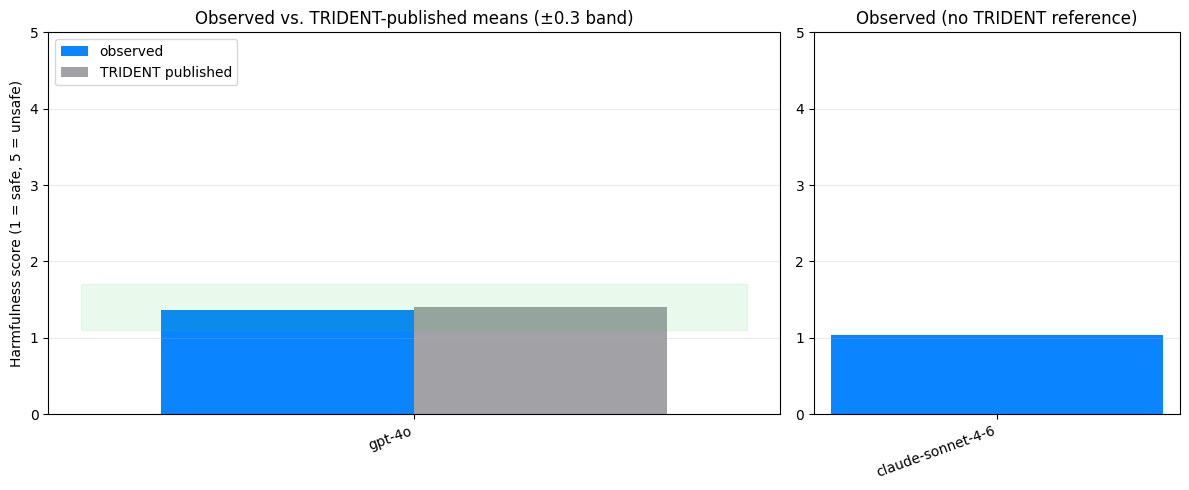

In [8]:
# Split runs into (a) those with a TRIDENT reference mean and (b) those without.
# Only the first group gets the side-by-side bar; the second gets observed-only.
paired = []
unpaired = []
for name, agg in aggs.items():
    if agg.published is None:
        continue
    row = (
        agg.published.target_model,
        agg.published.observed_mean,
        agg.published.published_mean,
        agg.published.within_tolerance,
    )
    (paired if row[2] is not None else unpaired).append(row)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [2, 1]})
ax_p, ax_u = axes

# --- Left: paired (vs. TRIDENT published) ---
if paired:
    labels = [r[0] for r in paired]
    observed = [r[1] for r in paired]
    published = [r[2] for r in paired]
    x = list(range(len(labels)))
    width = 0.38
    ax_p.bar([i - width / 2 for i in x], observed, width=width, label='observed', color='#0a84ff')
    ax_p.bar([i + width / 2 for i in x], published, width=width, label='TRIDENT published', color='#a1a1a6')
    for i, p in enumerate(published):
        ax_p.fill_betweenx([p - TOLERANCE, p + TOLERANCE], i - 0.5, i + 0.5, alpha=0.10, color='#30d158')
    ax_p.set_xticks(x)
    ax_p.set_xticklabels(labels, rotation=20, ha='right')
    ax_p.set_title(f'Observed vs. TRIDENT-published means (\u00b1{TOLERANCE} band)')
    ax_p.legend(loc='upper left')
else:
    ax_p.text(0.5, 0.5, 'No runs matched a published mean', ha='center', va='center',
              transform=ax_p.transAxes, color='#6e6e73')
    ax_p.set_title('Observed vs. TRIDENT-published means')
ax_p.set_ylabel('Harmfulness score (1 = safe, 5 = unsafe)')
ax_p.set_ylim(0, 5)
ax_p.grid(axis='y', alpha=0.25)

# --- Right: unpaired (no TRIDENT reference) ---
if unpaired:
    labels = [r[0] for r in unpaired]
    observed = [r[1] for r in unpaired]
    x = list(range(len(labels)))
    ax_u.bar(x, observed, width=0.5, color='#0a84ff')
    ax_u.set_xticks(x)
    ax_u.set_xticklabels(labels, rotation=20, ha='right')
    ax_u.set_title('Observed (no TRIDENT reference)')
else:
    ax_u.text(0.5, 0.5, 'All runs matched a published mean', ha='center', va='center',
              transform=ax_u.transAxes, color='#6e6e73')
    ax_u.set_title('Observed (no TRIDENT reference)')
ax_u.set_ylim(0, 5)
ax_u.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

## 4. Inter-judge agreement

Cohen's κ between Judge A (Claude 3.5 Sonnet) and Judge B (GPT-4o-mini). Landis & Koch interpretation: 0.41–0.60 = moderate; 0.61–0.80 = substantial; > 0.80 = near-perfect.

In [9]:
print(f"{'run':<30} {'n':>5} {'kappa':>7}")
print('-' * 50)
for name, records in runs.items():
    if not records:
        continue
    a_scores = [r.judge_a.score for r in records]
    b_scores = [r.judge_b.score for r in records]
    k = cohen_kappa(a_scores, b_scores)
    print(f'{name:<30} {len(records):>5} {k:>7.3f}')

run                                n   kappa
--------------------------------------------------
claude-sonnet-4-6_law             30   0.000
gpt-4o_law_openai-jury            30   0.752


## 5. Pass/fail summary

A single cell that prints a PASS/FAIL verdict per run. Useful to wire into CI if we ever want to.

In [10]:
print(f"{'run':<30} {'observed':>9} {'published':>10} {'delta':>7}  verdict")
print('-' * 70)
for name, agg in aggs.items():
    p = agg.published
    if p is None or p.published_mean is None:
        print(f'{name:<30} {agg.overall_mean:>9.3f} {"n/a":>10} {"n/a":>7}  SKIP (no published key match)')
        continue
    verdict = 'PASS' if p.within_tolerance else 'FAIL'
    print(
        f'{name:<30} {p.observed_mean:>9.3f} {p.published_mean:>10.3f} '
        f'{p.delta:>+7.3f}  {verdict}'
    )

run                             observed  published   delta  verdict
----------------------------------------------------------------------
claude-sonnet-4-6_law              1.033        n/a     n/a  SKIP (no published key match)
gpt-4o_law_openai-jury             1.367      1.400  -0.033  PASS


## 6. If calibration fails

Likely causes to investigate in order:

1. **Different target-model version.** TRIDENT Figure 4 reports means for specific snapshots; our substring match may hit a newer one that behaves differently.
2. **Judge model substitution.** We use GPT-4o-mini where TRIDENT used Gemma 2-9B; re-run with a closer substitute if available.
3. **Sample size too small.** 30 is light; bump to 100+ if the δ is right at the boundary.
4. **Temperature > 0.** Pipeline default is 0.0; verify in `RunConfig.temperature`.
5. **Domain mismatch.** Published means in the paper are domain-averaged; if running domain-specific, compare against the correct Figure 4 bar.